In [1]:
%pip install sympy casadi matplotlib scipy -q

Note: you may need to restart the kernel to use updated packages.


In [20]:
import sympy
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate

In [ ]:
class RoverModel:

    def __init__(self):

        # time
        self.t = sympy.symbols("t")
        self.delta = sympy.symbols("Delta")

        # state
        x = sympy.symbols("x")
        y = sympy.symbols("y")
        theta = sympy.symbols("theta")
        self.x = sympy.Matrix([x, y, theta])

        # covariance
        self.P = sympy.MatrixSymbol("P", 3, 3)

        # input
        u = sympy.symbols("u")
        omega = sympy.symbols("omega")
        self.u = sympy.Matrix([u, omega])

        # process noise
        w_v = sympy.symbols("w_v")  # process noise
        w_omega = sympy.symbols("w_omega")
        self.w = sympy.Matrix([w_v, w_omega])

        # measurement noise (just gps)
        v_x = sympy.symbols("v_x")
        v_y = sympy.symbols("v_y")
        self.v = sympy.Matrix([v_x, v_y])

        self.sigma_vx = sympy.symbols(r"sigma_vx")
        self.sigma_vy = sympy.symbols(r"sigma_vy")
        self.R = sympy.Matrix.diag(self.sigma_vx**2, self.sigma_vy**2)


    def dynamics(self):
        x = self.x[0]
        y = self.x[1]
        theta = self.x[2]
        v = self.u[0]
        omega = self.u[1]
        w_v = self.w[0]
        w_omega = self.w[1]
        cos = sympy.cos
        sin = sympy.sin
        x_dot = sympy.Matrix([
            (v + w_v)*cos(theta),
            (v + w_v)*sin(theta),
            (omega + w_omega)
        ])
        return x_dot

    def gps_measurement(self):
        v_x = self.v[0]
        v_y = self.v[1]
        x = self.x[0]
        y = self.x[1]
        return sympy.Matrix([x + v_x, y + v_y])

model = RoverModel()


check f_eval [0.5403023058681398, 0.8414709848078965, 1]
integration check   message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 1.000e+00  1.009e+00 ...  9.991e+00  1.000e+01]
        y: [[ 0.000e+00  9.009e-03 ...  4.203e-01  4.121e-01]
            [ 0.000e+00  4.058e-05 ...  1.907e+00  1.911e+00]
            [ 0.000e+00  9.009e-03 ...  8.991e+00  9.000e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 56
     njev: 0
      nlu: 0
ekf predict check ([1, 1, 1], array([[ 1.01000050e+00,  3.49269373e-06, -1.41825608e-02],
       [ 3.49269373e-06,  1.01002450e+00, -9.94942459e-02],
       [-1.41825608e-02, -9.94942459e-02,  1.01000000e+00]]))


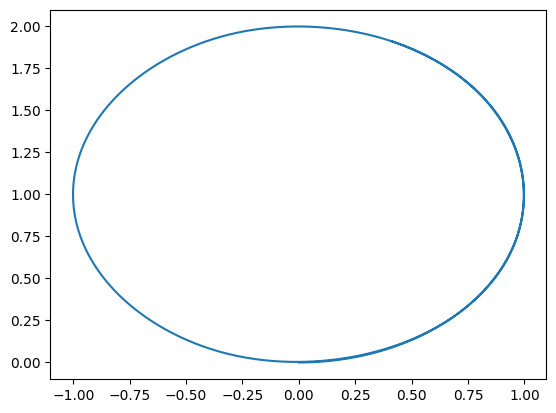

In [41]:
def derive_ekf():

    A = model.dynamics().jacobian(model.x)
    B = model.dynamics().jacobian(model.u)
    H = model.gps_measurement().jacobian(model.x)
    E = model.dynamics().jacobian(model.w)

    # discretized model
    Ad = (A*model.delta).exp()

    exp_int = sympy.integrate((A*model.t).exp(), (model.t, 0, model.delta))
    exp_int

    Bd = exp_int@B
    Ed = exp_int@E

    f_eval = sympy.lambdify(
        [model.x, model.u, model.w],
        model.dynamics().transpose().tolist()[0])

    res = f_eval(
        [1, 1, 1], [1, 1], [0,  0]
    )
    print('check f_eval', res)

    f_eval_const_u = lambda t, y: f_eval(y, [1, 1], [0, 0])

    # check integration
    t0 = 1
    tf = 10
    t_eval = np.linspace(t0, tf, 1000)
    res = scipy.integrate.solve_ivp(
        fun=f_eval_const_u,
        t_span=[t0, tf],
        y0=[0, 0, 0],
        t_eval=t_eval)
    print('integration check', res)
    plt.plot(res.y[0, :], res.y[1, :])
    

    # ekf prediction
    Ad0 = Ad.subs({ "w_v": 0, "w_omega": 0})
    Ed0 = Ed.subs({ "w_v": 0, "w_omega": 0})
    cov_v = 1
    cov_omega = 1
    Q = sympy.Matrix.diag(cov_v, cov_omega)
    Qd0 = Ed0 @ Q @ Ed0.T
    P1 = Ad0 @ model.P @ Ad0.T + Qd0  # Pk_k-1
    P1 = P1.as_explicit()
    f_P1 = sympy.lambdify([model.P, model.x, model.u, model.delta], P1)
    P1_eval = f_P1(np.eye(3), [1, 2, 3], [1, 1], 0.1)
    P1_eval

    def ekf_predict(P0, x0, u0, dt):
        x1 = [1, 1, 1]
        P1 = f_P1(P0, x0, u0, dt)
        w0 = [0, 0]
        f_eval_const_u = lambda t, x: f_eval(x, u0, w0)
        t_eval = [0, dt]
        res = scipy.integrate.solve_ivp(
            fun=f_eval_const_u, t_span=[0, dt], y0=[0, 0, 0], t_eval=t_eval)
        return x1, P1

    res = ekf_predict(np.eye(3), [1, 2, 3], [1, 1], 0.1)
    print('ekf predict check', res)
    

    # ekf correction
    S = (H@model.P@H.T + model.R).as_explicit()
    K = model.P@H.T@S.inv()
    K = K.as_explicit()
    K

    y_meas = sympy.MatrixSymbol('y_meas', 2, 1)

    y_tilde = (y_meas - H@model.x).as_explicit()

    x1 = (model.x + K@y_tilde).as_explicit()

    f_x1 = sympy.lambdify(
        [model.x, model.P, model.sigma_vx, model.sigma_vy, y_meas.as_explicit()],
        x1)

    f_x1([1, 2, 3], np.eye(3), 1, 1, [1, 2])

    def ekf_correct(P0, x0, y0, sigma_vx, sigma_vy, dt):
            x1 = f_x1(x0, P0, sigma_vx, sigma_vy, y0)
            P1 = (np.eye(3) - K@H)@P0
            return x1, P1

    return locals()

eqs = derive_ekf()

In [38]:
x1 = eqs['x1']
y_meas = eqs['y_meas']
f_x1 = sympy.lambdify([model.x, model.P, model.sigma_vx, model.sigma_vy, y_meas.as_explicit()], x1)
f_x1([1, 2, 3], np.eye(3), 1, 1, [1, 1])


array([[1. ],
       [1.5],
       [3. ]])

In [31]:
eqs['x1']

Matrix([
[    x + (-x + y_meas[0, 0])*((sigma_vy**2 + P[1, 1])*P[0, 0]/(sigma_vx**2*sigma_vy**2 + sigma_vx**2*P[1, 1] + sigma_vy**2*P[0, 0] + P[0, 0]*P[1, 1] - P[0, 1]*P[1, 0]) - P[0, 1]*P[1, 0]/(sigma_vx**2*sigma_vy**2 + sigma_vx**2*P[1, 1] + sigma_vy**2*P[0, 0] + P[0, 0]*P[1, 1] - P[0, 1]*P[1, 0])) + (-y + y_meas[1, 0])*((sigma_vx**2 + P[0, 0])*P[0, 1]/(sigma_vx**2*sigma_vy**2 + sigma_vx**2*P[1, 1] + sigma_vy**2*P[0, 0] + P[0, 0]*P[1, 1] - P[0, 1]*P[1, 0]) - P[0, 0]*P[0, 1]/(sigma_vx**2*sigma_vy**2 + sigma_vx**2*P[1, 1] + sigma_vy**2*P[0, 0] + P[0, 0]*P[1, 1] - P[0, 1]*P[1, 0]))],
[    y + (-x + y_meas[0, 0])*((sigma_vy**2 + P[1, 1])*P[1, 0]/(sigma_vx**2*sigma_vy**2 + sigma_vx**2*P[1, 1] + sigma_vy**2*P[0, 0] + P[0, 0]*P[1, 1] - P[0, 1]*P[1, 0]) - P[1, 0]*P[1, 1]/(sigma_vx**2*sigma_vy**2 + sigma_vx**2*P[1, 1] + sigma_vy**2*P[0, 0] + P[0, 0]*P[1, 1] - P[0, 1]*P[1, 0])) + (-y + y_meas[1, 0])*((sigma_vx**2 + P[0, 0])*P[1, 1]/(sigma_vx**2*sigma_vy**2 + sigma_vx**2*P[1, 1] + sigma_vy**2*P

# Covariance Prediction

$$ Q_d = E_d Q E_d^T $$

$$ P_{k|k-1} = A_d P_{k-1|k-1} A_d^T + Q_d $$

$S_k = H_k P_{k|k-1} H_k^T + R_k$

$K = PH^TS^{-1}$

In [178]:
S = (H@model.P@H.T + model.R).as_explicit()
K = model.P@H.T@S.inv()
K = K.as_explicit()
K

y_meas = sympy.MatrixSymbol('y_meas', 2, 1)

y_tilde = (y_meas - H@model.x).as_explicit()

x1 = (model.x + K@y_tilde).as_explicit()

#x1 = (model.x + K@sympy.Matrix([1, 1])).as_explicit()
#f_x1 = sympy.lambdify([model.x, model.P, model.sigma_vx, model.sigma_vy], x1)

#f_x1([1, 2, 3], np.eye(3), 1, 1)
x1

Matrix([
[    x + (-x + y_meas[0, 0])*((sigma_vy**2 + P[1, 1])*P[0, 0]/(sigma_vx**2*sigma_vy**2 + sigma_vx**2*P[1, 1] + sigma_vy**2*P[0, 0] + P[0, 0]*P[1, 1] - P[0, 1]*P[1, 0]) - P[0, 1]*P[1, 0]/(sigma_vx**2*sigma_vy**2 + sigma_vx**2*P[1, 1] + sigma_vy**2*P[0, 0] + P[0, 0]*P[1, 1] - P[0, 1]*P[1, 0])) + (-y + y_meas[1, 0])*((sigma_vx**2 + P[0, 0])*P[0, 1]/(sigma_vx**2*sigma_vy**2 + sigma_vx**2*P[1, 1] + sigma_vy**2*P[0, 0] + P[0, 0]*P[1, 1] - P[0, 1]*P[1, 0]) - P[0, 0]*P[0, 1]/(sigma_vx**2*sigma_vy**2 + sigma_vx**2*P[1, 1] + sigma_vy**2*P[0, 0] + P[0, 0]*P[1, 1] - P[0, 1]*P[1, 0]))],
[    y + (-x + y_meas[0, 0])*((sigma_vy**2 + P[1, 1])*P[1, 0]/(sigma_vx**2*sigma_vy**2 + sigma_vx**2*P[1, 1] + sigma_vy**2*P[0, 0] + P[0, 0]*P[1, 1] - P[0, 1]*P[1, 0]) - P[1, 0]*P[1, 1]/(sigma_vx**2*sigma_vy**2 + sigma_vx**2*P[1, 1] + sigma_vy**2*P[0, 0] + P[0, 0]*P[1, 1] - P[0, 1]*P[1, 0])) + (-y + y_meas[1, 0])*((sigma_vx**2 + P[0, 0])*P[1, 1]/(sigma_vx**2*sigma_vy**2 + sigma_vx**2*P[1, 1] + sigma_vy**2*P

In [133]:
x1

Matrix([
[    x + (-x + y[0, 0])*((\sigma_{vy}**2 + P[1, 1])*P[0, 0]/(\sigma_{vx}**2*\sigma_{vy}**2 + \sigma_{vx}**2*P[1, 1] + \sigma_{vy}**2*P[0, 0] + P[0, 0]*P[1, 1] - P[0, 1]*P[1, 0]) - P[0, 1]*P[1, 0]/(\sigma_{vx}**2*\sigma_{vy}**2 + \sigma_{vx}**2*P[1, 1] + \sigma_{vy}**2*P[0, 0] + P[0, 0]*P[1, 1] - P[0, 1]*P[1, 0])) + (-y + y[1, 0])*((\sigma_{vx}**2 + P[0, 0])*P[0, 1]/(\sigma_{vx}**2*\sigma_{vy}**2 + \sigma_{vx}**2*P[1, 1] + \sigma_{vy}**2*P[0, 0] + P[0, 0]*P[1, 1] - P[0, 1]*P[1, 0]) - P[0, 0]*P[0, 1]/(\sigma_{vx}**2*\sigma_{vy}**2 + \sigma_{vx}**2*P[1, 1] + \sigma_{vy}**2*P[0, 0] + P[0, 0]*P[1, 1] - P[0, 1]*P[1, 0]))],
[    y + (-x + y[0, 0])*((\sigma_{vy}**2 + P[1, 1])*P[1, 0]/(\sigma_{vx}**2*\sigma_{vy}**2 + \sigma_{vx}**2*P[1, 1] + \sigma_{vy}**2*P[0, 0] + P[0, 0]*P[1, 1] - P[0, 1]*P[1, 0]) - P[1, 0]*P[1, 1]/(\sigma_{vx}**2*\sigma_{vy}**2 + \sigma_{vx}**2*P[1, 1] + \sigma_{vy}**2*P[0, 0] + P[0, 0]*P[1, 1] - P[0, 1]*P[1, 0])) + (-y + y[1, 0])*((\sigma_{vx}**2 + P[0, 0])*P[1, 1